# Lattice Surgery on qLDPC Codes

End-to-end demo of `qldpc.experimental.surgery`:

- **§1** Single-PPM correctness
- **§2** Joint-PPM correctness
- **§3** Gadget construction and structural checks against published examples
- **§4** Short BB `[[72,12]]` logical-error-rate tutorial
- **§4.1** Cain `bb_18` resource comparison and offline benchmark workflow
- **§4.2** Short joint-PPM logical-error-rate tutorial

The notebook is intentionally bounded to run in under ten minutes on a typical multi-core developer workstation. Publication-scale Monte Carlo
collection lives in `experiments/lattice_surgery/collect_ler.py`, which supports resumable Sinter
runs and writes small aggregate CSV files.

This notebook demonstrates the public API of `qldpc.experimental.surgery`:

| Function | Returns | Purpose |
|---|---|---|
| `build_gadget(code, x, *, basis)` | `GadgetLayout` | Webster §II A gadget for measuring logical X̄ (`basis=Pauli.X`) or Z̄ (`basis=Pauli.Z`) |
| `build_bridge(g_l, g_r)` | `Bridge` | Universal adapter joining two gadgets for joint measurement |
| `build_single_ppm_circuit(g, *, rounds, noise_model, data_init)` | `stim.Circuit` | Single logical Pauli measurement circuit |
| `build_joint_ppm_circuit(g_l, g_r, bridge, *, rounds, noise_model, data_init)` | `(stim.Circuit, joint_code)` | Joint logical measurement |
| `boost_gadget(g, *, method, target, seed)` | `GadgetLayout` | Cheeger / BP+OSD-screened ancilla augmentation |
| `logical_state_init(code, state, *, log_idx)` | `str` | Per-qubit logical-state initialization |
| `cheeger_constant(g)` | `float` | Boundary Cheeger constant h(F) |
| `keep_only_observable(circuit, keep_idx)` | `stim.Circuit` | Retain one observable for LER collection |

References: Cain et al. arXiv:2603.28627; Webster, Smith, Cohen arXiv:2511.15989;
Cross et al. arXiv:2407.18393; Swaroop et al. arXiv:2410.03628.


## §0 Setup

In [1]:
%%capture
from pathlib import Path

repo = Path.cwd()
if not (repo / "pyproject.toml").exists():
    repo = repo.parent
install_target = str(repo)
%pip install -e "$install_target"
%pip install matplotlib

In [2]:
%matplotlib inline

import time

import matplotlib.pyplot as plt
import numpy as np
import sinter
import stim
import sympy

from qldpc import circuits, codes, decoders
from qldpc.circuits.noise_model import DepolarizingNoiseModel
from qldpc.experimental.surgery import (
    boost_gadget,
    build_bridge,
    build_gadget,
    build_joint_ppm_circuit,
    build_single_ppm_circuit,
    cheeger_constant,
    keep_only_observable,
    logical_state_init,
)
from qldpc.objects import Pauli

In [3]:
def raw_observables(circuit: stim.Circuit, shots: int) -> np.ndarray:
    """Compute raw ±1 observable values (XOR of designated measurements).

    Why not ``compile_detector_sampler(separate_observables=True)``?
    ──────────────────────────────────────────────────────────────────
      • ``compile_detector_sampler`` returns observable **flips relative to
        the noiseless reference**, i.e. ``actual XOR reference``. For a
        noiseless circuit, this is always 0 regardless of whether the
        underlying logical eigenvalue is +1 or −1. It's the right API for
        an LER sweep (we care about flips induced by noise), but it hides
        the sign of the logical outcome.

      • ``compile_sampler`` returns raw measurement records, from which we
        XOR the bits designated by each ``OBSERVABLE_INCLUDE`` line. The
        result IS the raw logical eigenvalue (0 ↔ +1, 1 ↔ −1), so the
        protocol's truth table — which initial state produces which sign —
        is directly visible. Use this API for noiseless correctness
        checks where the sign matters (truth tables, joint-parity tests).
    """
    sampler = circuit.compile_sampler()
    raw = sampler.sample(shots=shots).astype(np.uint8)
    n_meas = raw.shape[1]
    obs_lines = [ln for ln in str(circuit).splitlines() if ln.startswith("OBSERVABLE_INCLUDE")]
    cols = []
    for line in obs_lines:
        offsets = [int(t.strip("rec[]")) for t in line.split() if t.startswith("rec[")]
        meas_idx = [n_meas + off for off in offsets]
        cols.append(np.bitwise_xor.reduce(raw[:, meas_idx], axis=1))
    return np.stack(cols, axis=1)

## §1 Single-PPM correctness

### Minimal Example

[0 0 1 0 1 1 0]


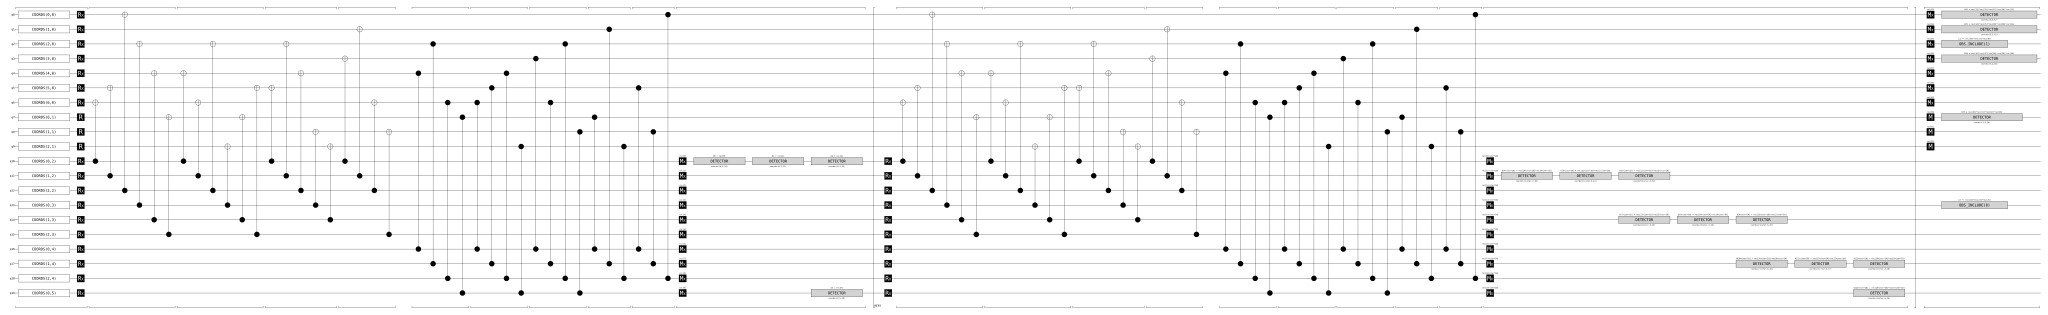

In [4]:
# code [[7, 1, 3]] single-PPM circuit.
#
# QUBIT_COORDS lane layout in the timeline-svg below (see
# _surgery_qubit_coordinates in src/qldpc/experimental/surgery/circuit.py):
#
#   y=0  data qubits             (code ids 0..6)
#   y=1  Q' ancillas             (one per data_check touching support = supp(X̄); Steane: 3)
#   y=2  data H_X ancillas       (measure the m_X original X stabilizers)
#   y=3  S_X' ancillas           (new X-type meas-checks; |support|=3 extended HX rows)
#   y=4  data H_Z ancillas       (measure the m_Z original Z stabilizers)
#   y=5  S_Z' ancillas           (gauge-fix Z-type rows from _step2_gauge_fix)
#
# (For basis=Z the S_X' ↔ S_Z' roles swap: y=3 holds the new Z-type meas-checks
#  and y=5 holds the X-type gauge-fix rows.)
#
# x coordinate inside each lane = the qubit's index within its lane group.
# For basis=X the lane assignment matches qubit ID order (0..6 on y=0,
# 7..9 on y=1, 10..12 on y=2, 13..15 on y=3, 16..18 on y=4, 19 on y=5),
# so the timeline-svg reads top-to-bottom in qubit ID order.
steane = codes.SteaneCode()
x_steane = np.asarray(steane.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
print(x_steane)
g = build_gadget(steane, x_steane, basis=Pauli.X)
circuit = build_single_ppm_circuit(g, rounds=3, noise_model=None, data_init="+")
circuit.diagram("timeline-svg")

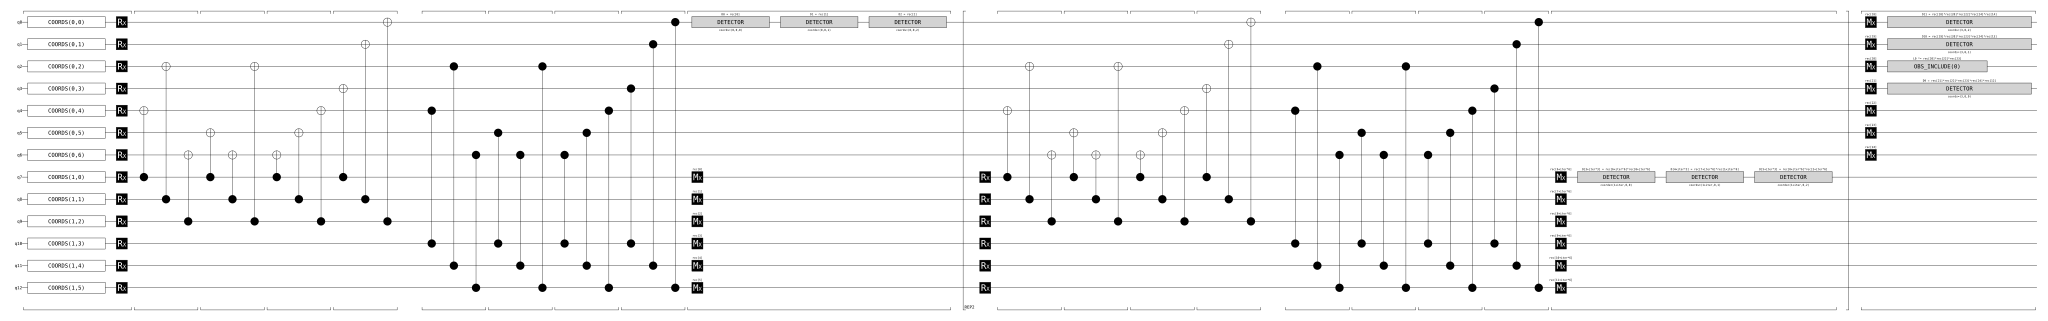

In [5]:
circuit = circuits.get_memory_experiment(steane, basis=Pauli.X, num_rounds=3)
circuit.diagram("timeline-svg")

### Truth table — scan the logical init on BB `[[36, 8]]`

Single-PPM measures the logical X̄ (`basis=Pauli.X`). `logical_state_init` returns the
per-qubit `data_init` string that prepares a given Pauli logical state: `"0"` and `"+"`
broadcast uniformly, while `"1"` and `"-"` place their flip on supp(X̄) and supp(Z̄)
respectively. That last detail is the reason the helper exists — a naive `"1" * n`
broadcast prepares the intended logical state only when those supports have odd weight,
and this code has an even-weight Z̄. The sign of X̄ is exposed by `obs0` *raw* (XOR of
physical measurement bits); see the `raw_observables` helper in §0 for why the
detector-sampler API would hide it.

| logical init | state | X̄ eigenvalue | expected `obs0` |
|---|---|---|---|
| `"0"` | $\|0\rangle_L$ | random ±1 (Z basis) | ~50% |
| `"1"` | $\|1\rangle_L$ | random ±1 (Z basis) | ~50% |
| `"+"` | $\|+\rangle_L$ | $+1$, since $\bar{X}\|+\rangle_L = +\|+\rangle_L$ | **0%** |
| `"-"` | $\|-\rangle_L$ | $-1$, since $\bar{X}\|-\rangle_L = -\|-\rangle_L$ | **100%** |

Because the prep targets the logical state itself rather than a transversal product
state, the X̄ eigenvalue does not depend on the parity of wt(X̄).

`obs0 == obs1` on every shot for all four inits (Webster Eq. 4 ≡ direct X̄_M).

In [6]:
# Swap in codes.SteaneCode() to run the same table on a self-dual code.
xs, ys = sympy.symbols("x y")
code = codes.BBCode({xs: 3, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
CODE_LABEL_1 = f"BB [[{code.num_qudits}, {code.dimension}]]"

x_code = np.asarray(code.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
z_code = np.asarray(code.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g_code = build_gadget(code, x_code, basis=Pauli.X)

SHOTS = 4000
# logical_state_init(code, state) returns the right per-qubit data_init for
# any CSS code — see surgery.logical_state_init docstring for the asymmetry
# explanation. Plug straight into data_init=.
table = [
    ("|0⟩_L", "0", "random", 0.5, True),
    ("|1⟩_L", "1", "random", 0.5, True),
    ("|+⟩_L", "+", "+1", 0.0, False),
    ("|−⟩_L", "-", "-1", 1.0, False),
]
print(
    f"{CODE_LABEL_1}: wt(X̄_0) = {int(x_code.sum())}, wt(Z̄_0) = {int(z_code.sum())}\n"
    f"logical_state_init places the |1⟩_L / |−⟩_L flip on those supports, so the X̄\n"
    f"eigenvalue below is independent of their parity.\n"
)
print(
    f"{'data':<6} | {'X̄ eigenvalue':<16} | {'expected obs0':<14} | "
    f"{'measured obs0 (frac=1)':<24} | obs0==obs1 | ok"
)
print("-" * 96)
for label, state, eig, expected, stochastic in table:
    circuit = build_single_ppm_circuit(
        g_code,
        rounds=3,
        noise_model=None,
        data_init=logical_state_init(code, state, log_idx=0),
    )
    # raw_observables (NOT compile_detector_sampler) — see §0 helper docstring.
    obs = raw_observables(circuit, SHOTS)
    rate0 = float(obs[:, 0].mean())
    agree = float((obs[:, 0] == obs[:, 1]).mean())
    if stochastic:
        ok = 0.4 < rate0 < 0.6 and agree == 1.0
        exp_str = "~50%"
    else:
        ok = rate0 == expected and agree == 1.0
        exp_str = f"{expected:>4.0%}"
    flag = "✓" if ok else "✗"
    print(
        f"{label:<6} | {eig:<16} | {exp_str:>14} | "
        f"{rate0:>10.2%} ({int(obs[:, 0].sum()):>4}/{SHOTS})    | "
        f"{agree:>7.1%}   | {flag}"
    )
    assert ok, f"failed for state={state!r}"
print(f"\n✓ single-PPM on {CODE_LABEL_1} measures X̄ correctly under all 4 logical inits")

BB [[36, 8]]: wt(X̄_0) = 6, wt(Z̄_0) = 8
logical_state_init places the |1⟩_L / |−⟩_L flip on those supports, so the X̄
eigenvalue below is independent of their parity.

data   | X̄ eigenvalue    | expected obs0  | measured obs0 (frac=1)   | obs0==obs1 | ok
------------------------------------------------------------------------------------------------


|0⟩_L  | random           |           ~50% |     50.88% (2035/4000)    |  100.0%   | ✓


|1⟩_L  | random           |           ~50% |     50.12% (2005/4000)    |  100.0%   | ✓


|+⟩_L  | +1               |             0% |      0.00% (   0/4000)    |  100.0%   | ✓


|−⟩_L  | -1               |           100% |    100.00% (4000/4000)    |  100.0%   | ✓

✓ single-PPM on BB [[36, 8]] measures X̄ correctly under all 4 logical inits


## §2 Joint-PPM correctness


### Minimal Example

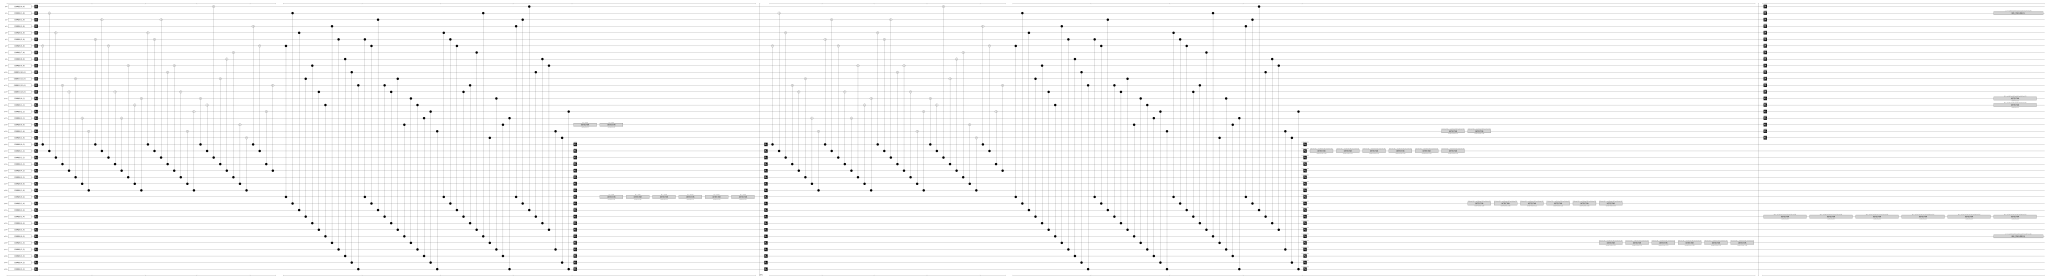

In [7]:
# Inter-code joint Z̄_1 ⊗ Z̄_2 on two Steane copies.
#
# QUBIT_COORDS lane layout in the timeline-svg below — same 6 lanes as single
# PPM, **concatenated** across c_l (left) and c_r (right), plus a 7th lane
# (y=6) for the bridge. Inside each lane, c_l qubits come first, then c_r:
#
#   y=0  data qubits             (c_l data ids 0..n_l-1, then c_r data; here both 7 each)
#   y=1  Q' ancillas             (one per data_check on support in each code; can include
#                                 bridge-augmented extras from build_bridge cellulation)
#   y=2  data H_X ancillas       (m_X^(l) checks first, then m_X^(r); intercode duplicates them)
#   y=3  S_Z' ancillas           (new Z-type meas-checks; |support^(l)| then |support^(r)|;
#                                 this cell is basis=Z — for basis=X this lane is S_X' instead)
#   y=4  data H_Z ancillas       (m_Z^(l) then m_Z^(r))
#   y=5  S_X' ancillas           (gauge-fix X-type rows; |gauge^(l)| then |gauge^(r)|;
#                                 for basis=X this lane is S_Z' instead)
#   y=6  bridge data + bridge cycle ancillas (the b ancillas that physically
#                                 join support^(l) and support^(r); only joint PPM uses this lane)
#
# Intracode joint (g_l.code is g_r.code) shares the y=0 data lane (no duplication)
# but still gets its own Q' / S_X' / S_Z' ancilla groups per gadget.
c1, c2 = codes.SteaneCode(), codes.SteaneCode()
z1 = np.asarray(c1.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
z2 = np.asarray(c2.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g1 = build_gadget(c1, z1, basis=Pauli.Z)
g2 = build_gadget(c2, z2, basis=Pauli.Z)
bridge = build_bridge(g1, g2)
rounds = 3  # any rounds >= 1 reads the same Z̄_1 ⊗ Z̄_2 parity

circuit_default, joint_code = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
)
circuit_default.diagram("timeline-svg")

### Truth table

Inter-code joint Z̄_1 ⊗ Z̄_2 measurement (`basis=Pauli.Z`) between Steane `[[7, 1, 3]]` and
BB `[[72, 12]]` — two different codes, to exercise the intercode path. The joint observable
should agree with the parity of the two individual Z̄ eigenvalues on every shot:

| init | Z̄_1 | Z̄_2 | parity (obs0) |
|---|---|---|---|
| $\|0\rangle\|0\rangle$ | +1 | +1 | 0 |
| $\|0\rangle\|1\rangle$ | +1 | -1 | 1 |
| $\|1\rangle\|0\rangle$ | -1 | +1 | 1 |
| $\|1\rangle\|1\rangle$ | -1 | -1 | 0 |

In [8]:
# Inter-code joint Z̄_1 ⊗ Z̄_2, code-agnostic via logical_state_init.
xs, ys = sympy.symbols("x y")
c1 = codes.SteaneCode()
c2 = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
z1 = np.asarray(c1.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
z2 = np.asarray(c2.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g1 = build_gadget(c1, z1, basis=Pauli.Z)
g2 = build_gadget(c2, z2, basis=Pauli.Z)
bridge = build_bridge(g1, g2)
rounds = 3  # any rounds >= 1 reads the same Z̄_1 ⊗ Z̄_2 parity

circuit_default, joint_code = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
)
wt1, wt2 = int(z1.sum()), int(z2.sum())
print(f"joint code           : [[{joint_code.num_qudits}, {joint_code.dimension}]]")
print(f"bridge.width         : {bridge.width}")
print(
    f"extra_ancilla_l, _r  : {bridge.extra_ancilla_l.shape[0]}, {bridge.extra_ancilla_r.shape[0]}"
)
print(
    f"wt(Z̄_1) = {wt1} ({'odd' if wt1 % 2 else 'even'}),  "
    f"wt(Z̄_2) = {wt2} ({'odd' if wt2 % 2 else 'even'})  "
    f"— logical_state_init handles either parity"
)
print()

SHOTS_JOINT = 1000
print(f"{'state':>16} | Z̄_1  Z̄_2 | expected obs0 | measured obs0 (frac=1)  | ok")
print("-" * 86)
joint_pass = True
for s1, s2, sign1, sign2, expected in [
    ("0", "0", "+1", "+1", 0),
    ("0", "1", "+1", "-1", 1),
    ("1", "0", "-1", "+1", 1),
    ("1", "1", "-1", "-1", 0),
]:
    label = f"|{s1}⟩_L|{s2}⟩_L"
    circuit, _ = build_joint_ppm_circuit(
        g1,
        g2,
        bridge,
        rounds=rounds,
        noise_model=None,
        data_init=(
            logical_state_init(c1, s1, log_idx=0),
            logical_state_init(c2, s2, log_idx=0),
        ),
    )
    obs = raw_observables(circuit, SHOTS_JOINT)
    rate = float(obs[:, 0].mean())
    ok = rate == float(expected)
    flag = "✓" if ok else "✗"
    print(
        f"{label:>16} | {sign1:>4}  {sign2:>4} | "
        f"{expected:>13} | {rate:>10.2%} ({int(obs[:, 0].sum()):>3}/{SHOTS_JOINT})    | {flag}"
    )
    joint_pass = joint_pass and ok

assert joint_pass, "joint-PPM correctness failed"
print("\n✓ joint Z̄_1 ⊗ Z̄_2 observable matches expected parity deterministically")

joint code           : [[106, 12]]
bridge.width         : 3
extra_ancilla_l, _r  : 0, 1
wt(Z̄_1) = 3 (odd),  wt(Z̄_2) = 14 (even)  — logical_state_init handles either parity

           state | Z̄_1  Z̄_2 | expected obs0 | measured obs0 (frac=1)  | ok
--------------------------------------------------------------------------------------


      |0⟩_L|0⟩_L |   +1    +1 |             0 |      0.00% (  0/1000)    | ✓


      |0⟩_L|1⟩_L |   +1    -1 |             1 |    100.00% (1000/1000)    | ✓


      |1⟩_L|0⟩_L |   -1    +1 |             1 |    100.00% (1000/1000)    | ✓


      |1⟩_L|1⟩_L |   -1    -1 |             0 |      0.00% (  0/1000)    | ✓

✓ joint Z̄_1 ⊗ Z̄_2 observable matches expected parity deterministically


**Superposition variant.** Tuple-form `data_init` lets each code take its own
logical init: `data_init=("0", "+")` puts `c1` in $|0\rangle_L$ (Z eigenstate)
and `c2` in $|+\rangle_L$ (X eigenstate, random in the Z basis). The joint
observable Z̄_1 ⊗ Z̄_2 then becomes random (Z̄_2 is random on $|+\rangle_L$),
and the two `OBSERVABLE_INCLUDE` paths (Webster §II B 2 bridged-product identity + cross-check) must
still agree on every shot — checking that the protocol works on genuinely
superposed states, not just classical product Pauli eigenstates.

In [9]:
# c1 in logical |0⟩_L, c2 in logical |+⟩_L. Per-code tuple form keeps intent
# obvious — each entry is broadcast across one code's data qubits.
circuit_super, _ = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
    data_init=(
        logical_state_init(c1, "0", log_idx=0),
        logical_state_init(c2, "+", log_idx=0),
    ),
)
obs_super = raw_observables(circuit_super, SHOTS_JOINT)
rate0_super = float(obs_super[:, 0].mean())
rate1_super = float(obs_super[:, 1].mean())
agree_super = float((obs_super[:, 0] == obs_super[:, 1]).mean())
print('c1 in |0⟩_L, c2 in |+⟩_L  (data_init=("0", "+")):')
print(f"  obs0 (joint PPM)         : {rate0_super:>6.1%} flips  (expected ~50% — Z̄_2 random)")
print(f"  obs1 (cross-check)  : {rate1_super:>6.1%} flips  (expected ~50%)")
print(f"  obs0 == obs1        : {agree_super:>6.1%}        (expected 100%)")
assert 0.4 < rate0_super < 0.6 and 0.4 < rate1_super < 0.6 and agree_super == 1.0
print("\n✓ joint observable is random (Z̄_2 ⟂ |+⟩) but obs0/obs1 agree on every shot")

c1 in |0⟩_L, c2 in |+⟩_L  (data_init=("0", "+")):
  obs0 (joint PPM)         :  51.0% flips  (expected ~50% — Z̄_2 random)
  obs1 (cross-check)  :  51.0% flips  (expected ~50%)
  obs0 == obs1        : 100.0%        (expected 100%)

✓ joint observable is random (Z̄_2 ⟂ |+⟩) but obs0/obs1 agree on every shot


## §3 Gadget construction vs published results

### §3.1 Webster Table 1 — bare-gadget qubit counts

Webster, Smith & Cohen arXiv:2511.15989 Table 1's "Gadget Qubits" column counts qubits
including ancillae, which for an L=1 gadget is |Q'| + |S_X'| + |S_Z'|. We reproduce it with
`build_gadget` for the X̄_1 seed on each of the 4 generalised-bicycle codes. For the last two
codes the table writes that cell as a sum, (49+8) and (79+20), whose second term is the
Cheeger-boost addition; the bare-gadget first term is what is compared here.

In [10]:
# Webster, Smith & Cohen, arXiv:2511.15989 Appendix A (seeds) and Table 1 (gadget qubits).
# Table 1's "Gadget Qubits" column is written as a sum for the last two codes, (49+8) and
# (79+20), whose second term is the Cheeger-boost addition; the value compared here is the
# bare-gadget first term.
# (ell, k, A exponents, B exponents, X_bar_1 left support, right support, bare gadget qubits)
WEBSTER_TABLE_1_CASES = [
    (31, 10, [0, 6, 15], [0, 5, 7], [1, 6, 8, 10], [11, 26], 19),
    (63, 12, [0, 4, 37], [0, 29, 49], [7, 12, 36, 41, 56], [1, 27, 31, 38, 61], 31),
    (
        127,
        14,
        [0, 32, 100],
        [0, 28, 49],
        [28, 47, 55, 75, 103, 114, 124],
        [4, 14, 15, 23, 50, 77, 83, 109, 123],
        49,
    ),
    (
        255,
        16,
        [0, 39, 55],
        [0, 70, 127],
        [18, 31, 35, 36, 91, 126, 146, 163, 164, 180, 196, 216, 233, 253],
        [48, 52, 87, 101, 103, 106, 107, 125, 140, 156, 179, 211],
        79,
    ),
]

print(f"{'Webster code':<22} {'X̄':<6} | |Q\u2032|  |S_X\u2032|  |S_Z\u2032|   sum  | Table 1")
print("-" * 80)
for code_index, (ell, k, a_exp, b_exp, x_left, x_right, published) in enumerate(
    WEBSTER_TABLE_1_CASES
):
    # Generalised bicycle code: H_X = [A | B], H_Z = [B.T | A.T] over GF(2).
    shift = np.roll(np.eye(ell, dtype=np.int_), shift=-1, axis=0)
    A = sum(np.linalg.matrix_power(shift, exponent) for exponent in a_exp) % 2
    B = sum(np.linalg.matrix_power(shift, exponent) for exponent in b_exp) % 2
    code = codes.CSSCode(np.hstack([A, B]), np.hstack([B.T, A.T]), is_subsystem_code=False)
    x = np.zeros(2 * ell, dtype=np.uint8)
    x[x_left] = 1
    x[ell + np.asarray(x_right)] = 1
    g = build_gadget(code, x, basis=Pauli.X)
    # basis=X: |Q'| = incidence rows (one κ per row); |S_X'| = support; |S_Z'| = gauge rows.
    n_anc, n_X, n_Z = g.incidence.shape[0], len(g.support), g.gauge.shape[0]
    total = n_anc + n_X + n_Z
    label, op = f"[[{2 * ell}, {k}]]", "X̄_1"
    flag = "✓" if total == published else "✗"
    print(
        f"{label:<22} {op:<6} | {n_anc:>4}  {n_X:>6}  {n_Z:>6}   {total:>5}  | "
        f"{published:>5}  {flag}"
    )
    assert total == published, f"Webster code {code_index} ancilla mismatch"
print("\n✓ bare-gadget qubit count matches Table 1 for all 4 codes")

Webster code           X̄     | |Q′|  |S_X′|  |S_Z′|   sum  | Table 1
--------------------------------------------------------------------------------
[[62, 10]]             X̄_1   |    9       6       4      19  |    19  ✓
[[126, 12]]            X̄_1   |   15      10       6      31  |    31  ✓
[[254, 14]]            X̄_1   |   24      16       9      49  |    49  ✓


[[510, 16]]            X̄_1   |   39      26      14      79  |    79  ✓

✓ bare-gadget qubit count matches Table 1 for all 4 codes


### §3.2 Cain `bb_18` Resource gadget — (39, 20, 20) with degree 7

Cain et al. arXiv:2603.28627 Extended Data Table 3, the `bb_18` **Resource**
row, reports `(Qubits, X-checks, Z-checks) = (39, 20, 20)` and **merged-code
degree = 7**. The same table's `bb_18` *Processor* row is a different, larger
gadget, `(189, 104, 86)` at degree 9.

Only two of the triple's three numbers are independent: |S_X′| equals wt(Z̄), so it
is fixed by choosing a weight-20 representative, and Webster's step 3 then forces
|S_Z′| = |Q′| − wt(Z̄) + 1 = 39 − 20 + 1 = 20. The substantive matches are therefore
|Q′| = 39 and the degree. Reproduction:

1. Build `bb_18` from the Cain App. A 2 Eq. (A11) polynomials.
2. Use a **cached weight-20 Z̄ representative** + a **fixed boost seed**.
   Both the Z̄ rep (found offline once via BP+OSD + greedy stabilizer
   reduction) and the boost seed are picked so the final merged code
   matches Cain's degree-7 row, not just its `(|Q'|, |S_X'|, |S_Z'|)` triple.
   Different reps / seeds yield different bare gadgets and boost
   trajectories — most don't reach degree 7, so we hand-select.
3. Run `build_gadget` for the gadget construction.
4. Run `boost_gadget(method='combinatorial', seed=2)` to add extra ancilla
   qubits until the Cheeger constant `h(F) ≥ 1` (Webster's distance-preservation
   threshold).

In [11]:
print("Step 1: Cain App. A 2 Eq. (A11): bb_18 with l=31, m=4")
print("  a = 1 + x^6 y + x^27")
print("  b = y^2 + x^15 y^3 + x^24")
xs, ys = sympy.symbols("x y")
bb18 = codes.BBCode((31, 4), 1 + xs**6 * ys + xs**27, ys**2 + xs**15 * ys**3 + xs**24)
print(f"  built: [[{bb18.num_qubits}, {bb18.dimension}]]  (expected [[248, 10]])")
assert (bb18.num_qubits, bb18.dimension) == (248, 10)

# Cached weight-20 Z̄ representative + fixed boost seed. The pair (rep, seed)
# is the smallest deterministic bundle that reproduces BOTH of Cain's bb_18
# Resource numbers — (|Q'|, |S_X'|, |S_Z'|) = (39, 20, 20) AND merged-code
# degree = 7 (max stab weight in HX_merged ∪ HZ_merged). Most wt-20 reps boost
# to the right triple but a degree of 8–10 because Webster's gauge-fix S_Z' rows
# (the canonical gauge basis is not weight-minimized) sit on many
# Q' ancilla qubits at once. This particular pair keeps all S_Z' rows ≤ wt 7.
print("\nStep 2: load cached wt-20 Z̄ rep")
Z_BAR_SUPPORT = [
    8,
    9,
    14,
    18,
    24,
    34,
    40,
    56,
    75,
    76,
    97,
    111,
    122,
    171,
    202,
    208,
    213,
    218,
    228,
    238,
]
BOOST_SEED = 2
vec_20 = np.zeros(bb18.num_qudits, dtype=np.uint8)
vec_20[Z_BAR_SUPPORT] = 1
# Sanity: vec_20 is a Z-logical (H_X @ vec_20 == 0).
assert not ((np.asarray(bb18.matrix_x).astype(int) @ vec_20) % 2).any(), (
    "vec_20 is not in ker(H_X) — not a Z-logical"
)
print(f"  wt(Z̄) = {int(vec_20.sum())}")

print("\nStep 3: build_gadget")
# swap (matrix_z ↔ matrix_x) so vec_20 (a Z̄ on bb18) becomes the X̄ on target_code
target_code = codes.CSSCode(bb18.matrix_z, bb18.matrix_x, is_subsystem_code=False)
g_bb = build_gadget(target_code, vec_20, basis=Pauli.X)
# basis=X: |Q'| = incidence rows (one κ per row); |S_X'| = support (new X-type checks);
#          |S_Z'| = gauge rows (new Z-type gauge-fix checks).
print(
    f"  bare gadget: (|Q'|={g_bb.incidence.shape[0]}, |S_X'|={len(g_bb.support)}, |S_Z'|={g_bb.gauge.shape[0]})"
)

print(f"\nStep 4: boost_gadget (combinatorial, target h=1.0, seed={BOOST_SEED})")
g_bb_boosted = boost_gadget(
    g_bb, method="combinatorial", target=1.0, max_extra_qubits=20, seed=BOOST_SEED
)
n_Q_b = g_bb_boosted.incidence.shape[0]
n_X_b = len(g_bb_boosted.support)
n_Z_b = g_bb_boosted.gauge.shape[0]
HX_m = np.asarray(g_bb_boosted.HX_merged).astype(int)
HZ_m = np.asarray(g_bb_boosted.HZ_merged).astype(int)
degree = max(int(HX_m.sum(1).max()), int(HZ_m.sum(1).max()))
print(f"  boost added +{n_Q_b - g_bb.incidence.shape[0]} Q\u2032 qubits")
print(f"  boosted gadget : (|Q\u2032|={n_Q_b}, |S_X\u2032|={n_X_b}, |S_Z\u2032|={n_Z_b})")
print(f"  merged degree  : {degree}  (= max stab weight over HX_merged ∪ HZ_merged)")
print("\n  Cain Extended Data Table 3: (39, 20, 20), degree 7")
assert (n_Q_b, n_X_b, n_Z_b) == (39, 20, 20), (
    f"got ({n_Q_b}, {n_X_b}, {n_Z_b}), expected (39, 20, 20)"
)
assert degree == 7, f"got degree {degree}, expected 7"
print("  ✓ EXACT MATCH on (|Q\u2032|, |S_X\u2032|, |S_Z\u2032|) AND degree")

Step 1: Cain App. A 2 Eq. (A11): bb_18 with l=31, m=4
  a = 1 + x^6 y + x^27
  b = y^2 + x^15 y^3 + x^24
  built: [[248, 10]]  (expected [[248, 10]])

Step 2: load cached wt-20 Z̄ rep
  wt(Z̄) = 20

Step 3: build_gadget
  bare gadget: (|Q'|=30, |S_X'|=20, |S_Z'|=11)

Step 4: boost_gadget (combinatorial, target h=1.0, seed=2)


  boost added +9 Q′ qubits
  boosted gadget : (|Q′|=39, |S_X′|=20, |S_Z′|=20)
  merged degree  : 7  (= max stab weight over HX_merged ∪ HZ_merged)

  Cain Extended Data Table 3: (39, 20, 20), degree 7
  ✓ EXACT MATCH on (|Q′|, |S_X′|, |S_Z′|) AND degree


#### Reproducing the cached representative

The weight-20 representative and boost seed above were found by a stochastic BP+OSD search. That
search is deliberately not part of the tutorial: it is expensive, nondeterministic, and produces no
new API behavior. The checked-in pair makes the construction deterministic.

For publication-scale LER collection on this gadget, use:

```bash
python experiments/lattice_surgery/collect_ler.py \
    --preset bb18 --max-shots 10000 --max-errors 100 --workers 8 \
    --output bb18_results.csv
```


### §3.3 Structural distance screen on BB `[[72,12,6]]`

Cross et al. arXiv:2407.18393 §3.3 Thm 6 is a distance-preservation theorem. For the L=1 gadgets
built here, its expansion condition reduces to `h(F) ≥ 1`, together with the theorem's
irreducibility assumptions. The live check below verifies the computable structural inputs:

1. construct the published BB `[[72,12,6]]` code;
2. confirm the bare gadget has `h(F) ≥ 1`;
3. confirm the merged checks commute; and
4. confirm the merged code fixes exactly one logical constraint.

Randomized distance searches do not prove the theorem and can take a long, variable amount of time,
so they are not run in this tutorial.


In [12]:
xs, ys = sympy.symbols("x y")
bb72 = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
x_bb72 = np.asarray(bb72.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_bb72 = build_gadget(bb72, x_bb72, basis=Pauli.X)
h_72 = cheeger_constant(g_bb72)
merged_bb72 = codes.CSSCode(
    g_bb72.HX_merged,
    g_bb72.HZ_merged,
    is_subsystem_code=False,
)
commutator = (
    np.asarray(merged_bb72.matrix_x).astype(int) @ np.asarray(merged_bb72.matrix_z).astype(int).T
) % 2

print(f"input code    : [[{bb72.num_qudits}, {bb72.dimension}, 6]]")
print(f"Cheeger h(F)  : {h_72:.3f}")
print(f"merged code   : [[{merged_bb72.num_qudits}, {merged_bb72.dimension}]]")
assert h_72 >= 1.0
assert not commutator.any()
assert merged_bb72.dimension == bb72.dimension - 1
print("✓ structural distance-screen inputs hold")

input code    : [[72, 12, 6]]
Cheeger h(F)  : 1.000
merged code   : [[84, 11]]
✓ structural distance-screen inputs hold


### §3.4 Structural screen on Cain `bb_18` `[[248,10]]`

The same live checks apply to the boosted Resource gadget from §3.2. Cain reports only an upper
bound `d ≤ 18`, so a randomized upper-bound comparison cannot establish distance preservation and
is omitted. Publication-scale Monte Carlo generation is available through the offline runner linked
below in §4.1.


In [13]:
h_bb18 = cheeger_constant(g_bb_boosted)
merged_bb18 = codes.CSSCode(
    g_bb_boosted.HX_merged,
    g_bb_boosted.HZ_merged,
    is_subsystem_code=False,
)
commutator = (
    np.asarray(merged_bb18.matrix_x).astype(int) @ np.asarray(merged_bb18.matrix_z).astype(int).T
) % 2

print(f"input code    : [[{target_code.num_qudits}, {target_code.dimension}, ≤18]]")
print(f"Cheeger h(F)  : {h_bb18:.3f}")
print(f"merged code   : [[{merged_bb18.num_qudits}, {merged_bb18.dimension}]]")
assert h_bb18 >= 1.0
assert not commutator.any()
assert merged_bb18.dimension == target_code.dimension - 1
print("✓ structural distance-screen inputs hold")

input code    : [[248, 10, ≤18]]
Cheeger h(F)  : 1.000
merged code   : [[287, 9]]
✓ structural distance-screen inputs hold


## §4 Short LER tutorial on the `[[72,12]]` BB code

This section demonstrates Sinter task construction, BP+LSD decoding, uncertainty reporting, and
plotting. It is intentionally a **tutorial estimate**, not a publication-quality benchmark:

- three physical-error rates: `0.0014`, `0.0019`, `0.0025`;
- at most 10,000 shots, with a 20-error stopping target that batches may overshoot; and
- up to eight workers, capped by the host CPU count.

The curves have only a few tens of errors, so their relative surgery/memory ordering is **not
resolved** by this run. Use the offline runner for high-statistics conclusions.


In [14]:
xs, ys = sympy.symbols("x y")
bbcode = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
x_bbcode = np.asarray(bbcode.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_bbcode = build_gadget(bbcode, x_bbcode, basis=Pauli.X)

h_bbcode = cheeger_constant(g_bbcode)
print(f"code         : [[{bbcode.num_qudits}, {bbcode.dimension}]]")
print(f"Cheeger h(F) : {h_bbcode:.3f}  (Webster threshold = 1.0)")
if h_bbcode < 1.0:
    print("→ boosting (h < 1.0)")
    g_bbcode = boost_gadget(
        g_bbcode, method="combinatorial", target=1.0, max_extra_qubits=20, seed=3
    )
    # gadget notation: F → incidence.
    print(
        f"→ boosted F shape: {g_bbcode.incidence.shape}, h(F_aug) = {cheeger_constant(g_bbcode):.3f}"
    )
else:
    print("→ h ≥ 1.0, no boost needed")

code         : [[72, 12]]
Cheeger h(F) : 1.000  (Webster threshold = 1.0)
→ h ≥ 1.0, no boost needed


In [15]:
LER_ROUNDS = 9
LER_P_VALUES = [0.0014, 0.0019, 0.0025]
import os

LER_MAX_SHOTS = 10_000
LER_MAX_ERRORS = 20
LER_NUM_WORKERS = max(1, min(8, os.cpu_count() or 1))

surgery_tasks, memory_tasks = [], []
for p in LER_P_VALUES:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    surgery = build_single_ppm_circuit(g_bbcode, rounds=LER_ROUNDS, noise_model=noise)
    surgery_tasks.append(
        sinter.Task(
            circuit=keep_only_observable(surgery, keep_idx=0),
            json_metadata={"p": float(p), "kind": "surgery"},
        )
    )
    memory = circuits.get_memory_experiment(
        bbcode,
        basis=Pauli.X,
        num_rounds=LER_ROUNDS,
        noise_model=noise,
    )
    memory_tasks.append(
        sinter.Task(
            circuit=keep_only_observable(memory, keep_idx=0),
            json_metadata={"p": float(p), "kind": "memory"},
        )
    )

decoder = decoders.SinterDecoder(
    with_BP_LSD=True,
    max_iter=20,
    bp_method="ms",
    lsd_method="lsd_cs",
    lsd_order=5,
)

t0 = time.time()
results = sinter.collect(
    tasks=surgery_tasks + memory_tasks,
    decoders=["custom"],
    custom_decoders={"custom": decoder},
    num_workers=LER_NUM_WORKERS,
    max_shots=LER_MAX_SHOTS,
    max_errors=LER_MAX_ERRORS,
    print_progress=False,
)
print(f"collected {len(results)} task results in {time.time() - t0:.1f}s")

collected 6 task results in 146.2s


In [16]:
surgery_lers, memory_lers = {}, {}
for r in results:
    p = r.json_metadata["p"]
    kind = r.json_metadata["kind"]
    ler = r.errors / max(r.shots, 1)
    (surgery_lers if kind == "surgery" else memory_lers)[p] = (ler, r.errors, r.shots)

print(f"{'p':>10} | {'surgery LER':>22} | {'memory LER':>22}")
print(f"{'-' * 10} | {'-' * 22} | {'-' * 22}")
for p in sorted(LER_P_VALUES):
    s, se, ss = surgery_lers.get(p, (np.nan, 0, 0))
    m, me, ms = memory_lers.get(p, (np.nan, 0, 0))
    print(f"{p:>10.4f} | {s:>10.3e} ({se:>3}/{ss:<6}) | {m:>10.3e} ({me:>3}/{ms:<6})")

         p |            surgery LER |             memory LER
---------- | ---------------------- | ----------------------
    0.0014 |  5.000e-04 (  5/10000 ) |  3.000e-04 (  3/10000 )
    0.0019 |  1.400e-03 ( 14/10000 ) |  8.000e-04 (  8/10000 )
    0.0025 |  7.022e-03 ( 24/3418  ) |  3.723e-03 ( 23/6178  )


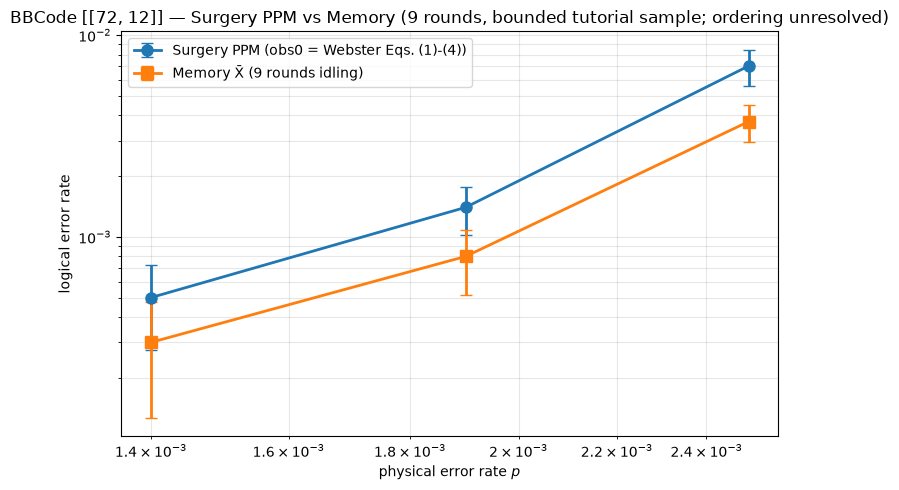

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ps_sorted = sorted(LER_P_VALUES)


def _ler_with_sigma(table, label):
    """Point estimate and Poisson 1-sigma band. A point with no errors gets the sqrt(1) stand-in.

    A zero-error point has ler = 0, which the log y-axis below cannot draw, so it would vanish from
    the figure without a trace. Those points are named here; decide whether to plot them as an upper
    limit or to move the sweep range so every point has countable errors.
    """
    ler = np.array([table[p][0] for p in ps_sorted])
    counts = np.array([table[p][1] for p in ps_sorted], dtype=float)
    shots = np.array([table[p][2] for p in ps_sorted], dtype=float)
    zero = [p for p, n in zip(ps_sorted, counts) if n == 0]
    if zero:
        print(f"  WARNING {label}: no errors at p in {zero} -- dropped by the log axis")
    return ler, np.sqrt(np.maximum(counts, 1.0)) / shots


surgery_y, surgery_sigma = _ler_with_sigma(surgery_lers, "surgery")
memory_y, memory_sigma = _ler_with_sigma(memory_lers, "memory")
ax.errorbar(
    ps_sorted,
    surgery_y,
    yerr=surgery_sigma,
    fmt="o-",
    label="Surgery PPM (obs0 = Webster Eqs. (1)-(4))",
    markersize=8,
    linewidth=2,
    capsize=4,
)
ax.errorbar(
    ps_sorted,
    memory_y,
    yerr=memory_sigma,
    fmt="s-",
    label=f"Memory X̄ ({LER_ROUNDS} rounds idling)",
    markersize=8,
    linewidth=2,
    capsize=4,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("physical error rate $p$")
ax.set_ylabel("logical error rate")
ax.set_title(
    f"BBCode [[{bbcode.num_qudits}, {bbcode.dimension}]] — Surgery PPM vs Memory "
    f"({LER_ROUNDS} rounds, bounded tutorial sample; ordering unresolved)"
)
ax.legend(loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## §4.1 Cain `bb_18` resource comparison

The `bb_18` circuit is useful for comparing resource scale, but not for a live notebook LER sweep.
Existing measurements take roughly 60–100 CPU-seconds **per surgery shot**; even eight workers need
many hours for useful statistics.

The live cell below builds one 15-round surgery task and one 9-round memory task, then compares their detector-error-model sizes. The round mismatch is intentional and is printed explicitly.
Publication-scale collection is resumable through:

```bash
python experiments/lattice_surgery/collect_ler.py \
    --preset bb18 --max-shots 10000 --max-errors 100 --workers 8 \
    --output bb18_results.csv
```

This Resource gadget is smaller than the Processor gadget used in Cain et al. Extended Data Fig. 1b,
and the offline script uses a single BP+LSD instance rather than Cain's five-instance ensemble. It
therefore does not claim to reproduce that figure.


In [18]:
from qldpc.circuits.noise_model import DepolarizingNoiseModel

RESOURCE_P = 0.007
resource_noise = DepolarizingNoiseModel(RESOURCE_P, include_idling_error=False)
resource_surgery = build_single_ppm_circuit(
    g_bb_boosted,
    rounds=15,
    noise_model=resource_noise,
)
resource_memory = circuits.get_memory_experiment(
    target_code,
    basis=Pauli.X,
    num_rounds=9,
    noise_model=resource_noise,
)
dem_surgery = keep_only_observable(resource_surgery, keep_idx=0).detector_error_model()
dem_memory = keep_only_observable(resource_memory, keep_idx=0).detector_error_model()

print(f"bb_18 [[{target_code.num_qudits}, {target_code.dimension}]] at p={RESOURCE_P}")
print(
    f"  surgery DEM (15 rounds): n_det={dem_surgery.num_detectors}  n_err={dem_surgery.num_errors}"
)
print(f"  memory DEM  (9 rounds): n_det={dem_memory.num_detectors}  n_err={dem_memory.num_errors}")
print(
    f"  ratio      : n_det ×{dem_surgery.num_detectors / dem_memory.num_detectors:.1f}"
    f"  n_err ×{dem_surgery.num_errors / dem_memory.num_errors:.1f}"
)

bb_18 [[248, 10]] at p=0.007
  surgery DEM (15 rounds): n_det=4320  n_err=179983
  memory DEM  (9 rounds): n_det=1240  n_err=13640
  ratio      : n_det ×3.5  n_err ×13.2


## §4.2 Short joint-PPM LER tutorial

Inter-code `Z̄_l ⊗ Z̄_r` surgery on two Steane codes, using the bridged-product identity of Webster
§II B 2. This is another bounded tutorial estimate: three error rates, at most 10,000 shots, and a 20-error stopping target that batches may
overshoot, and the same BP+LSD decoder as §4.


In [19]:
# === §4.2 setup: swap `make_code()` + `CODE_LABEL` to test other CSS codes ===
CODE_LABEL = "Steane [[7,1,3]]"


def make_code():
    return codes.SteaneCode()
    # BB examples (uncomment to swap):
    # xs, ys = sympy.symbols("x y")
    # return codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)  # [[72, 12]]
    # return codes.BBCode({xs: 3, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)  # [[36, 8]]


LOGICAL_BASIS = Pauli.Z
LOGICAL_IDX = 0  # index into code.get_logical_ops(LOGICAL_BASIS)
BOOST_TARGET = 1.0  # Webster Cheeger threshold h(F) ≥ 1
BOOST_MAX_EXTRA_QUBITS = 20
BOOST_SEED = 3

# === Generic setup (no code-specific code below this line) ===
code_l_j, code_r_j = make_code(), make_code()
logical_op = np.asarray(code_l_j.get_logical_ops(LOGICAL_BASIS)[LOGICAL_IDX]).astype(np.uint8)
g_l_j = build_gadget(code_l_j, logical_op, basis=LOGICAL_BASIS)
g_r_j = build_gadget(code_r_j, logical_op, basis=LOGICAL_BASIS)

# Cheeger boost (no-op if h ≥ target on both sides; BB-style codes often need it).
for side, getter, setter in (
    ("l", lambda: g_l_j, lambda v: globals().__setitem__("g_l_j", v)),
    ("r", lambda: g_r_j, lambda v: globals().__setitem__("g_r_j", v)),
):
    g = getter()
    h = cheeger_constant(g)
    if h < BOOST_TARGET:
        boosted = boost_gadget(
            g,
            method="combinatorial",
            target=BOOST_TARGET,
            max_extra_qubits=BOOST_MAX_EXTRA_QUBITS,
            seed=BOOST_SEED,
        )
        setter(boosted)
        h_after = cheeger_constant(boosted)
        print(f"  side={side}: h={h:.3f} < {BOOST_TARGET} → boosted to h={h_after:.3f}")
    else:
        print(f"  side={side}: h={h:.3f} ≥ {BOOST_TARGET} ✓ (no boost)")

bridge_j = build_bridge(g_l_j, g_r_j)
print()
print(f"code            : {CODE_LABEL}  (basis={LOGICAL_BASIS.name}, logical[{LOGICAL_IDX}])")
print(f"left/right code : [[{code_l_j.num_qudits}, {code_l_j.dimension}]]")
print(f"bridge          : width={bridge_j.width}, basis={bridge_j.basis.name}")

smoke_circuit_j, joint_code_j = build_joint_ppm_circuit(
    g_l_j,
    g_r_j,
    bridge_j,
    rounds=3,
    noise_model=None,
)
print(f"merged code     : [[{joint_code_j.num_qudits}, {joint_code_j.dimension}]]")
print(
    f"observables     : {smoke_circuit_j.num_observables} (obs0 = Webster joint, obs1 = direct cross-check)"
)

  side=l: h=1.000 ≥ 1.0 ✓ (no boost)
  side=r: h=1.000 ≥ 1.0 ✓ (no boost)

code            : Steane [[7,1,3]]  (basis=Z, logical[0])
left/right code : [[7, 1]]
bridge          : width=3, basis=Z
merged code     : [[21, 1]]
observables     : 2 (obs0 = Webster joint, obs1 = direct cross-check)


In [20]:
LER_ROUNDS_J = 9
LER_P_VALUES_J = [0.002, 0.004, 0.008]
LER_MAX_SHOTS_J = 10_000
LER_MAX_ERRORS_J = 20
LER_NUM_WORKERS_J = max(1, min(8, os.cpu_count() or 1))

surgery_tasks_j, memory_tasks_j = [], []
for p in LER_P_VALUES_J:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    surgery = build_joint_ppm_circuit(
        g_l_j,
        g_r_j,
        bridge_j,
        rounds=LER_ROUNDS_J,
        noise_model=noise,
    )[0]
    surgery_tasks_j.append(
        sinter.Task(
            circuit=keep_only_observable(surgery, keep_idx=0),
            json_metadata={"p": float(p), "kind": "joint_surgery"},
        )
    )
    memory = circuits.get_memory_experiment(
        make_code(),
        basis=LOGICAL_BASIS,
        num_rounds=LER_ROUNDS_J,
        noise_model=noise,
    )
    memory_tasks_j.append(
        sinter.Task(
            circuit=keep_only_observable(memory, keep_idx=0),
            json_metadata={"p": float(p), "kind": "single_memory"},
        )
    )

decoder_j = decoders.SinterDecoder(
    with_BP_LSD=True,
    max_iter=20,
    bp_method="ms",
    lsd_method="lsd_cs",
    lsd_order=5,
)

t0 = time.time()
results_j = sinter.collect(
    tasks=surgery_tasks_j + memory_tasks_j,
    decoders=["custom"],
    custom_decoders={"custom": decoder_j},
    num_workers=LER_NUM_WORKERS_J,
    max_shots=LER_MAX_SHOTS_J,
    max_errors=LER_MAX_ERRORS_J,
    print_progress=False,
)
print(f"collected {len(results_j)} task results in {time.time() - t0:.1f}s")

collected 6 task results in 2.7s


In [21]:
joint_surg_lers_j, single_mem_lers_j = {}, {}
for r in results_j:
    p = r.json_metadata["p"]
    kind = r.json_metadata["kind"]
    ler = r.errors / max(r.shots, 1)
    (joint_surg_lers_j if kind == "joint_surgery" else single_mem_lers_j)[p] = (
        ler,
        r.errors,
        r.shots,
    )

print(f"{'p':>10} | {'joint Z̄Z̄ surgery':>22} | {'single-code memory':>22}")
print(f"{'-' * 10} | {'-' * 22} | {'-' * 22}")
for p in sorted(LER_P_VALUES_J):
    s, se, ss = joint_surg_lers_j.get(p, (np.nan, 0, 0))
    m, me, ms = single_mem_lers_j.get(p, (np.nan, 0, 0))
    print(f"{p:>10.4f} | {s:>10.3e} ({se:>3}/{ss:<6}) | {m:>10.3e} ({me:>3}/{ms:<6})")

         p |     joint Z̄Z̄ surgery |     single-code memory
---------- | ---------------------- | ----------------------
    0.0020 |  1.716e-02 ( 58/3379  ) |  6.014e-02 ( 78/1297  )
    0.0040 |  4.726e-02 ( 50/1058  ) |  1.154e-01 ( 63/546   )
    0.0080 |  1.425e-01 ( 62/435   ) |  2.271e-01 (124/546   )


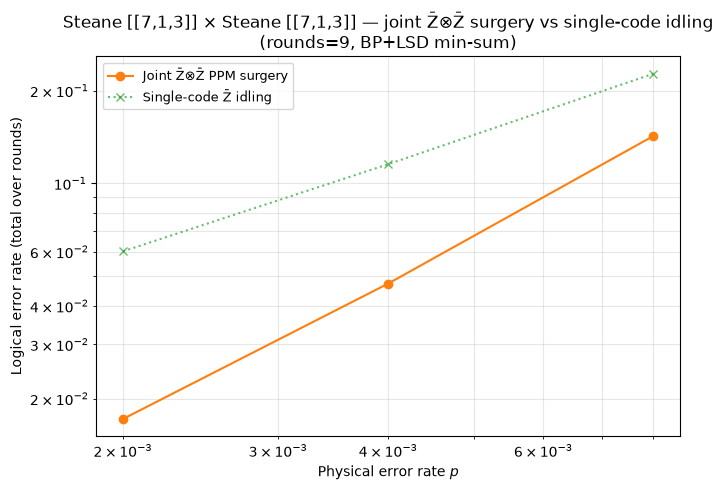

In [22]:
ps_j = sorted(LER_P_VALUES_J)
surg_y_j = [joint_surg_lers_j[p][0] for p in ps_j]
mem_y_j = [single_mem_lers_j[p][0] for p in ps_j]

fig_j, ax_j = plt.subplots(figsize=(7, 5))
ax_j.loglog(ps_j, surg_y_j, "o-", color="C1", label="Joint Z̄⊗Z̄ PPM surgery")
ax_j.loglog(ps_j, mem_y_j, "x:", color="C2", alpha=0.7, label="Single-code Z̄ idling")
ax_j.set_xlabel("Physical error rate $p$")
ax_j.set_ylabel("Logical error rate (total over rounds)")
ax_j.set_title(
    f"{CODE_LABEL} × {CODE_LABEL} — joint Z̄⊗Z̄ surgery vs single-code idling\n"
    f"(rounds={LER_ROUNDS_J}, BP+LSD min-sum)"
)
ax_j.legend(loc="upper left", fontsize=9)
ax_j.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()